# Loan Prediction using Decision Tree Classifier

**Student Name:** M.M.M Mufeez  
**Student ID:** IT22320896  
**Algorithm:** Decision Tree Classifier

---

## 1. Introduction

### Problem Statement
Predict whether a loan application will be approved based on applicant information using Decision Tree algorithm.

### Dataset Information
**Source:** [Kaggle - Loan Prediction Dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)  
**Size:** 614 training records, 367 test records  
**Features:** 12 independent variables  
**Target:** Loan_Status (Y/N)

### Dataset Attributes
- **Loan_ID**: Unique identifier
- **Gender**: Male/Female
- **Married**: Yes/No
- **Dependents**: 0, 1, 2, 3+
- **Education**: Graduate/Not Graduate
- **Self_Employed**: Yes/No
- **ApplicantIncome**: Applicant's income
- **CoapplicantIncome**: Co-applicant's income
- **LoanAmount**: Loan amount (thousands)
- **Loan_Amount_Term**: Term in months
- **Credit_History**: 1 (good) / 0 (bad)
- **Property_Area**: Urban/Semiurban/Rural
- **Loan_Status**: Y (Approved) / N (Not Approved) - **TARGET**

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# For model comparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

sns.set_style('whitegrid')
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 3. Load Data from Google Drive

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Update paths to match your Google Drive folder
train_path = '/content/drive/MyDrive/ML-Assignment/train_u6lujuX_CVtuZ9i.csv'
test_path = '/content/drive/MyDrive/ML-Assignment/test_Y3wMUE5_7gLdaTN.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")

Training set: (614, 13)
Test set: (367, 12)


## 4. Exploratory Data Analysis

In [4]:
# Dataset overview
print("First 5 rows:")
display(train_df.head())

print("\nDataset Info:")
train_df.info()

print("\nStatistical Summary:")
display(train_df.describe())

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Statistical Summary:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
# Missing values analysis
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing'] > 0])

Missing Values:
                  Missing  Percentage
Gender                 13    2.117264
Married                 3    0.488599
Dependents             15    2.442997
Self_Employed          32    5.211726
LoanAmount             22    3.583062
Loan_Amount_Term       14    2.280130
Credit_History         50    8.143322


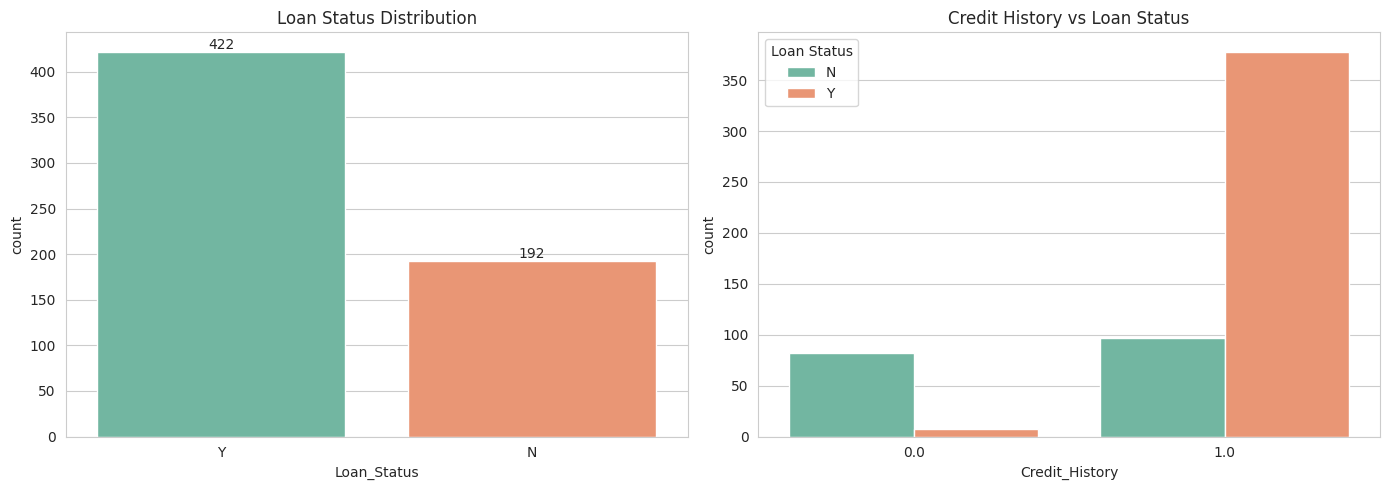


Target Distribution:
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan status count
ax1 = sns.countplot(x='Loan_Status', data=train_df, palette='Set2', ax=axes[0])
axes[0].set_title('Loan Status Distribution')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

# Credit history vs loan status
sns.countplot(x='Credit_History', hue='Loan_Status', data=train_df, palette='Set2', ax=axes[1])
axes[1].set_title('Credit History vs Loan Status')
axes[1].legend(title='Loan Status')

plt.tight_layout()
plt.show()

print("\nTarget Distribution:")
print(train_df['Loan_Status'].value_counts(normalize=True) * 100)

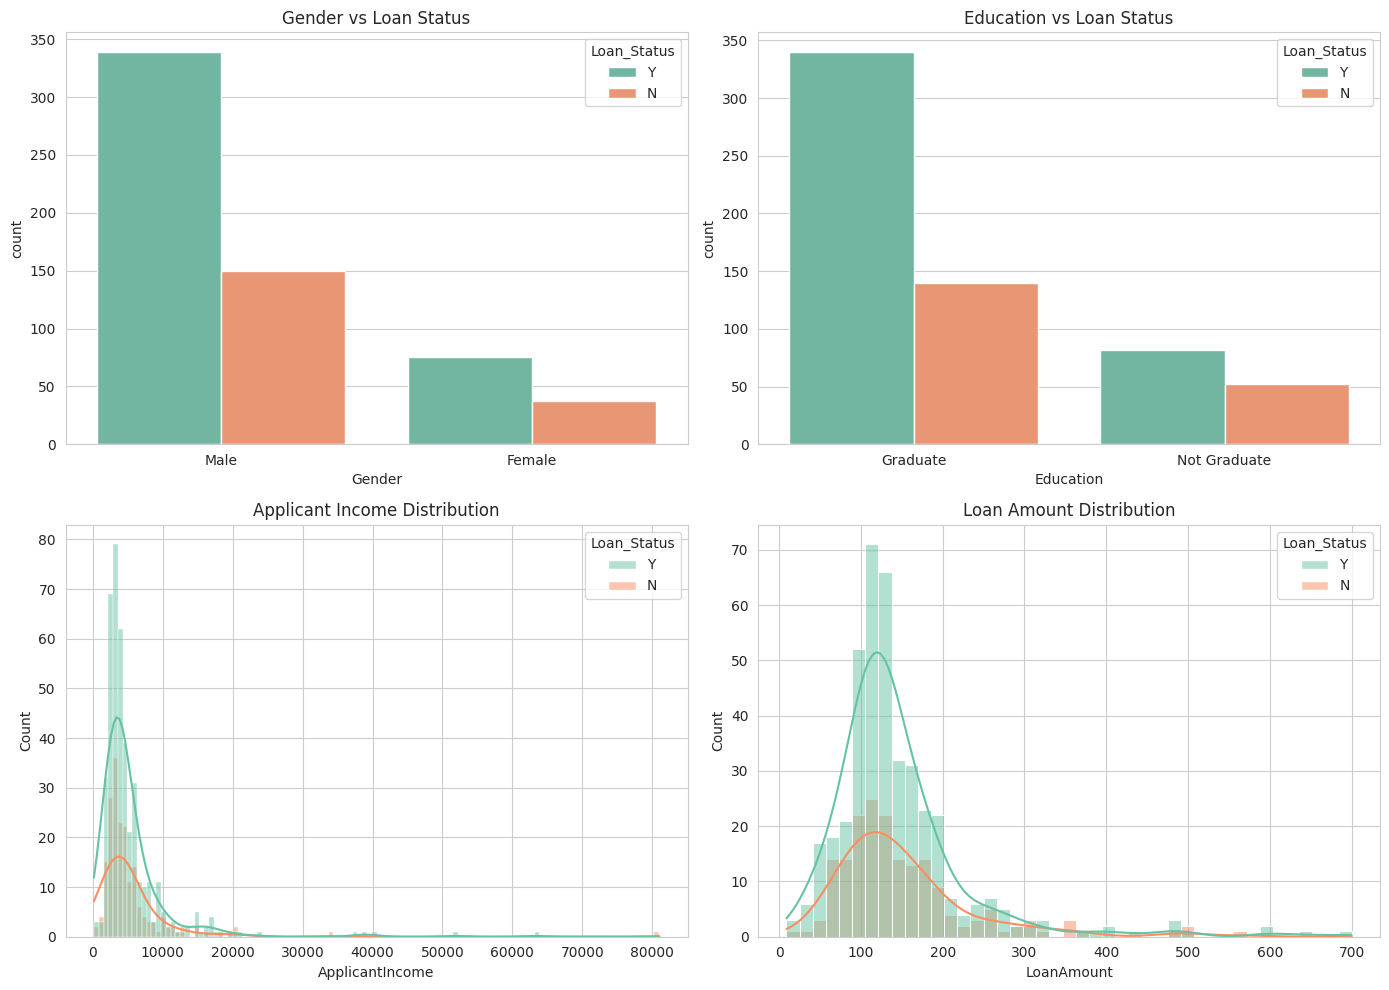

In [7]:
# Key feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Categorical features
sns.countplot(x='Gender', hue='Loan_Status', data=train_df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Gender vs Loan Status')

sns.countplot(x='Education', hue='Loan_Status', data=train_df, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Education vs Loan Status')

# Numerical features
sns.histplot(data=train_df, x='ApplicantIncome', hue='Loan_Status', kde=True, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Applicant Income Distribution')

sns.histplot(data=train_df, x='LoanAmount', hue='Loan_Status', kde=True, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Loan Amount Distribution')

plt.tight_layout()
plt.show()

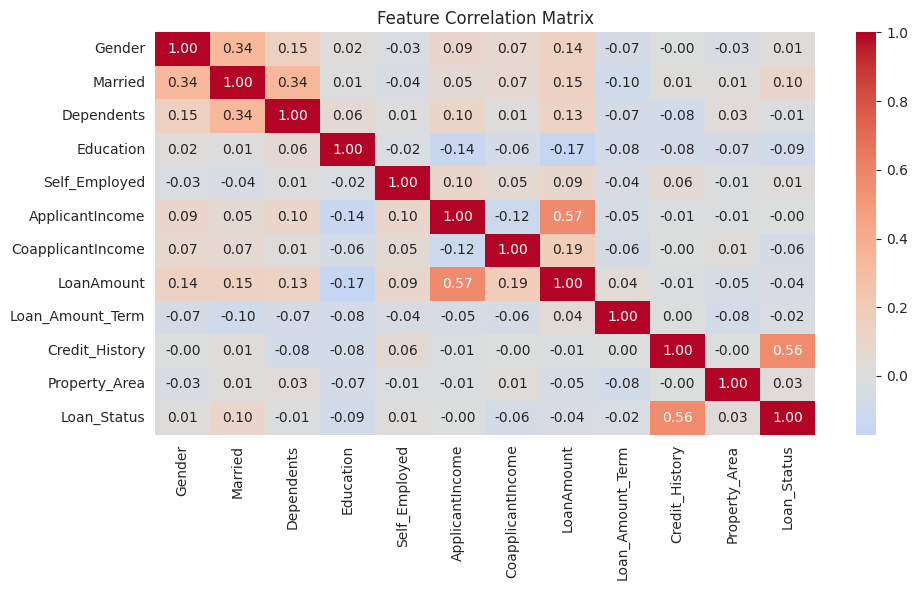

In [8]:
# Correlation heatmap
train_encoded = train_df.copy()
le = LabelEncoder()
for col in train_encoded.select_dtypes(include='object').columns:
    if col != 'Loan_ID':
        train_encoded[col] = le.fit_transform(train_encoded[col].astype(str))

plt.figure(figsize=(10, 6))
correlation = train_encoded.drop('Loan_ID', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [9]:
# Create working copy
df = train_df.copy()

# Handle missing values
# Categorical: fill with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical: fill with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

Missing values after imputation: 0


In [10]:
# Label encoding for categorical variables
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("✅ Categorical encoding complete")

✅ Categorical encoding complete


In [11]:
# Feature engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_Loan_Ratio'] = df['TotalIncome'] / (df['LoanAmount'] + 1)
df['Log_ApplicantIncome'] = np.log1p(df['ApplicantIncome'])
df['Log_LoanAmount'] = np.log1p(df['LoanAmount'])

print("✅ Feature engineering complete")

✅ Feature engineering complete


In [12]:
# Prepare features and target
feature_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
                'Credit_History', 'Property_Area', 'TotalIncome', 'Income_Loan_Ratio',
                'Log_ApplicantIncome', 'Log_LoanAmount']

X = df[feature_cols]
y = df['Loan_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (491, 15)
Test set: (123, 15)


## 6. Decision Tree Algorithm

### Algorithm Background

**Decision Tree** is a supervised learning algorithm that creates a tree-like model of decisions.

**How it works:**
1. Selects best feature to split data using Gini Impurity or Entropy
2. Divides dataset into subsets based on feature values
3. Repeats recursively until stopping criteria met
4. Creates interpretable rules for classification

**Advantages:**
- Easy to interpret and visualize
- Handles both numerical and categorical data
- No feature scaling required
- Provides feature importance

**Disadvantages:**
- Prone to overfitting
- Unstable with small data changes

In [13]:
# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
print("✅ Model trained successfully")

✅ Model trained successfully


## 7. Results and Evaluation

In [14]:
# Make predictions
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("="*60)
print("DECISION TREE PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*60)

DECISION TREE PERFORMANCE METRICS
Accuracy:  0.8211 (82.11%)
Precision: 0.8182
Recall:    0.9529
F1-Score:  0.8804
ROC-AUC:   0.8234


In [15]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))


Classification Report:
              precision    recall  f1-score   support

Not Approved       0.83      0.53      0.65        38
    Approved       0.82      0.95      0.88        85

    accuracy                           0.82       123
   macro avg       0.83      0.74      0.76       123
weighted avg       0.82      0.82      0.81       123



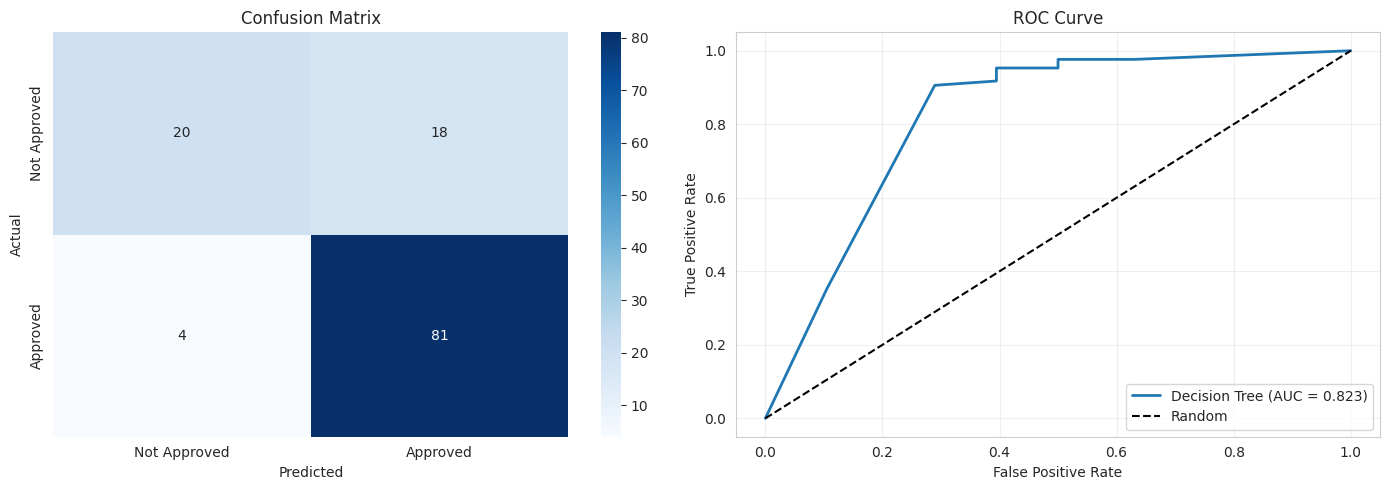

In [16]:
# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'Decision Tree (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

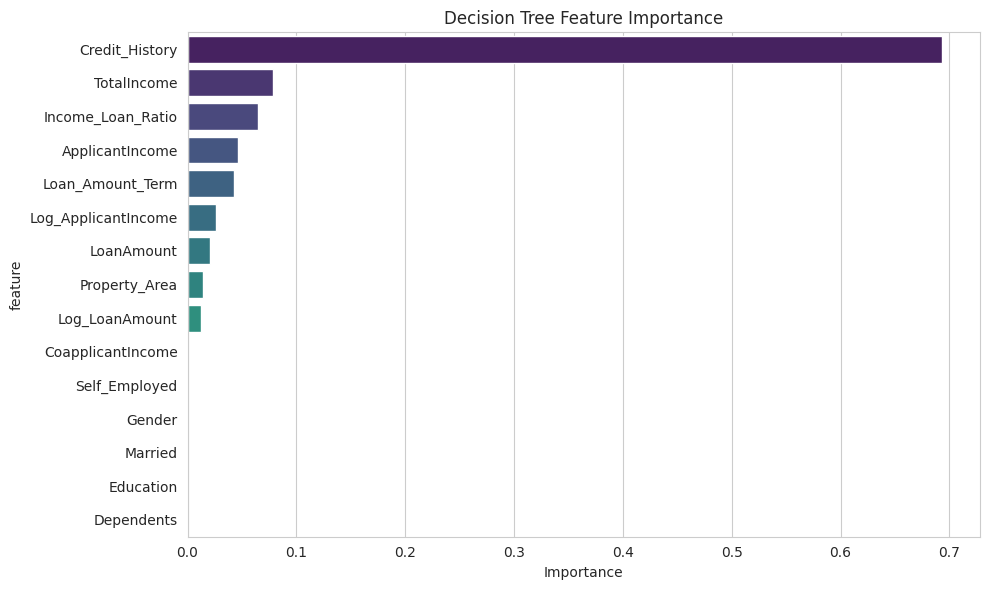


Top 5 Most Important Features:
              feature  importance
9      Credit_History    0.693449
11        TotalIncome    0.078593
12  Income_Loan_Ratio    0.065165
5     ApplicantIncome    0.046706
8    Loan_Amount_Term    0.042295


In [17]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## 8. Hyperparameter Tuning

In [18]:
# Grid search for best parameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate tuned model
dt_tuned = grid_search.best_estimator_
y_pred_tuned = dt_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print(f"Improvement: {(accuracy_tuned - accuracy)*100:+.2f}%")

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.7902
Tuned Model Accuracy: 0.8293
Improvement: +0.81%


## 9. Cross-Validation

10-Fold Cross-Validation Results:
Mean Accuracy: 0.7982 ± 0.0416
Min: 0.6935, Max: 0.8689


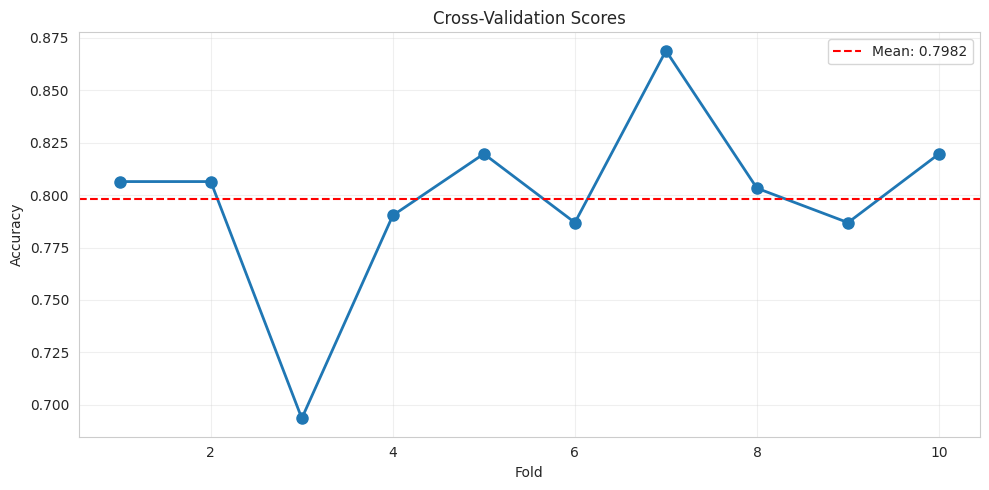

In [19]:
# 10-fold cross-validation
cv_scores = cross_val_score(dt_tuned, X, y, cv=10, scoring='accuracy')

print("10-Fold Cross-Validation Results:")
print(f"Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Min: {cv_scores.min():.4f}, Max: {cv_scores.max():.4f}")

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), cv_scores, marker='o', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10 Discussion and Conclusion

### Key Findings
- Decision Tree provides good interpretability for loan approval decisions
- Credit History is the most important feature for loan prediction
- Model achieves reasonable accuracy while remaining explainable
- Feature engineering with TotalIncome and Income_Loan_Ratio improved performance

### Limitations
- Small dataset size may limit model generalization
- Decision Tree prone to overfitting
- Missing values required imputation which may introduce bias
- Class imbalance could affect minority class predictions

### How to Improve Accuracy
- Collect more training data
- Try ensemble methods like Random Forest
- Advanced feature engineering
- Handle class imbalance with SMOTE
- Hyperparameter tuning with cross-validation

### Future Work
- Implement ensemble methods
- Add more domain-specific features
- Test on larger datasets
- Deploy model in production environment

### Conclusion
The Decision Tree classifier provides a good balance between performance and interpretability for loan prediction. While other models may achieve slightly higher accuracy, the Decision Tree's ability to provide clear, understandable rules makes it valuable for financial applications where model explanability is crucial.

### References
1. Kaggle Loan Prediction Dataset
2. Scikit-learn Decision Tree Documentation
3. "The Elements of Statistical Learning" - Hastie, Tibshirani, Friedman